In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi']= 300
from scipy.special import roots_legendre

In [2]:
# set cross section
LX = 100 #width
NEL = 80 #number of elements

dx = np.ones(NEL) * LX // NEL
NEL2COORD = np.cumsum(dx) - dx // 2

SigT = np.ones(NEL) * 0.0181
SigS = np.zeros(NEL) * 1
Qm = np.ones(NEL) / (2 * np.pi)

In [3]:
# set quadrature 
NQ = 4
dtheta = 2 * np.pi / NQ
theta = (np.arange(NQ) + 0.5) * dtheta
w = np.full(NQ, dtheta)
mu = np.cos(theta)


In [ ]:
def WDDTransportSweep(SigT, Qm, dx, w, mu):
    NX = len(dx)
    NM = len(w)
    
    psis = np.zeros((NM, NX + 1))
    psi = np.zeros((NM, NX))
    phi = np.zeros(NX)
    
    for m in range(NM):
        if mu[m] > 0.0:
            startX = 0
            stopX  = NX
            stepX = 1
            delta_Xin = 0
            delta_Xout = 1
        else:
            startX = NX - 1
            stopX  = -1
            stepX = -1
            delta_Xin = 1
            delta_Xout = 0
            
        for i in range(startX, stopX, stepX):
            iin = i + delta_Xin
            iout = i + delta_Xout
            a = 1/2
            Sm = SigS[i] * phi[i] / 2
            psis[m, iout] = ((Sm + Qm[i]) * dx[i]+ (np.abs(mu[m]) - (1 - a) * SigT[i]) * psis[m, iin]) / (np.abs(mu[m]) + a * SigT[i] * dx[i]) 
            psi[m, i] = a*psis[m, iout] + (1-a)*psis[m, iin]
            
            phi[i] += psi[m, i] * w[m]

    return phi, psi

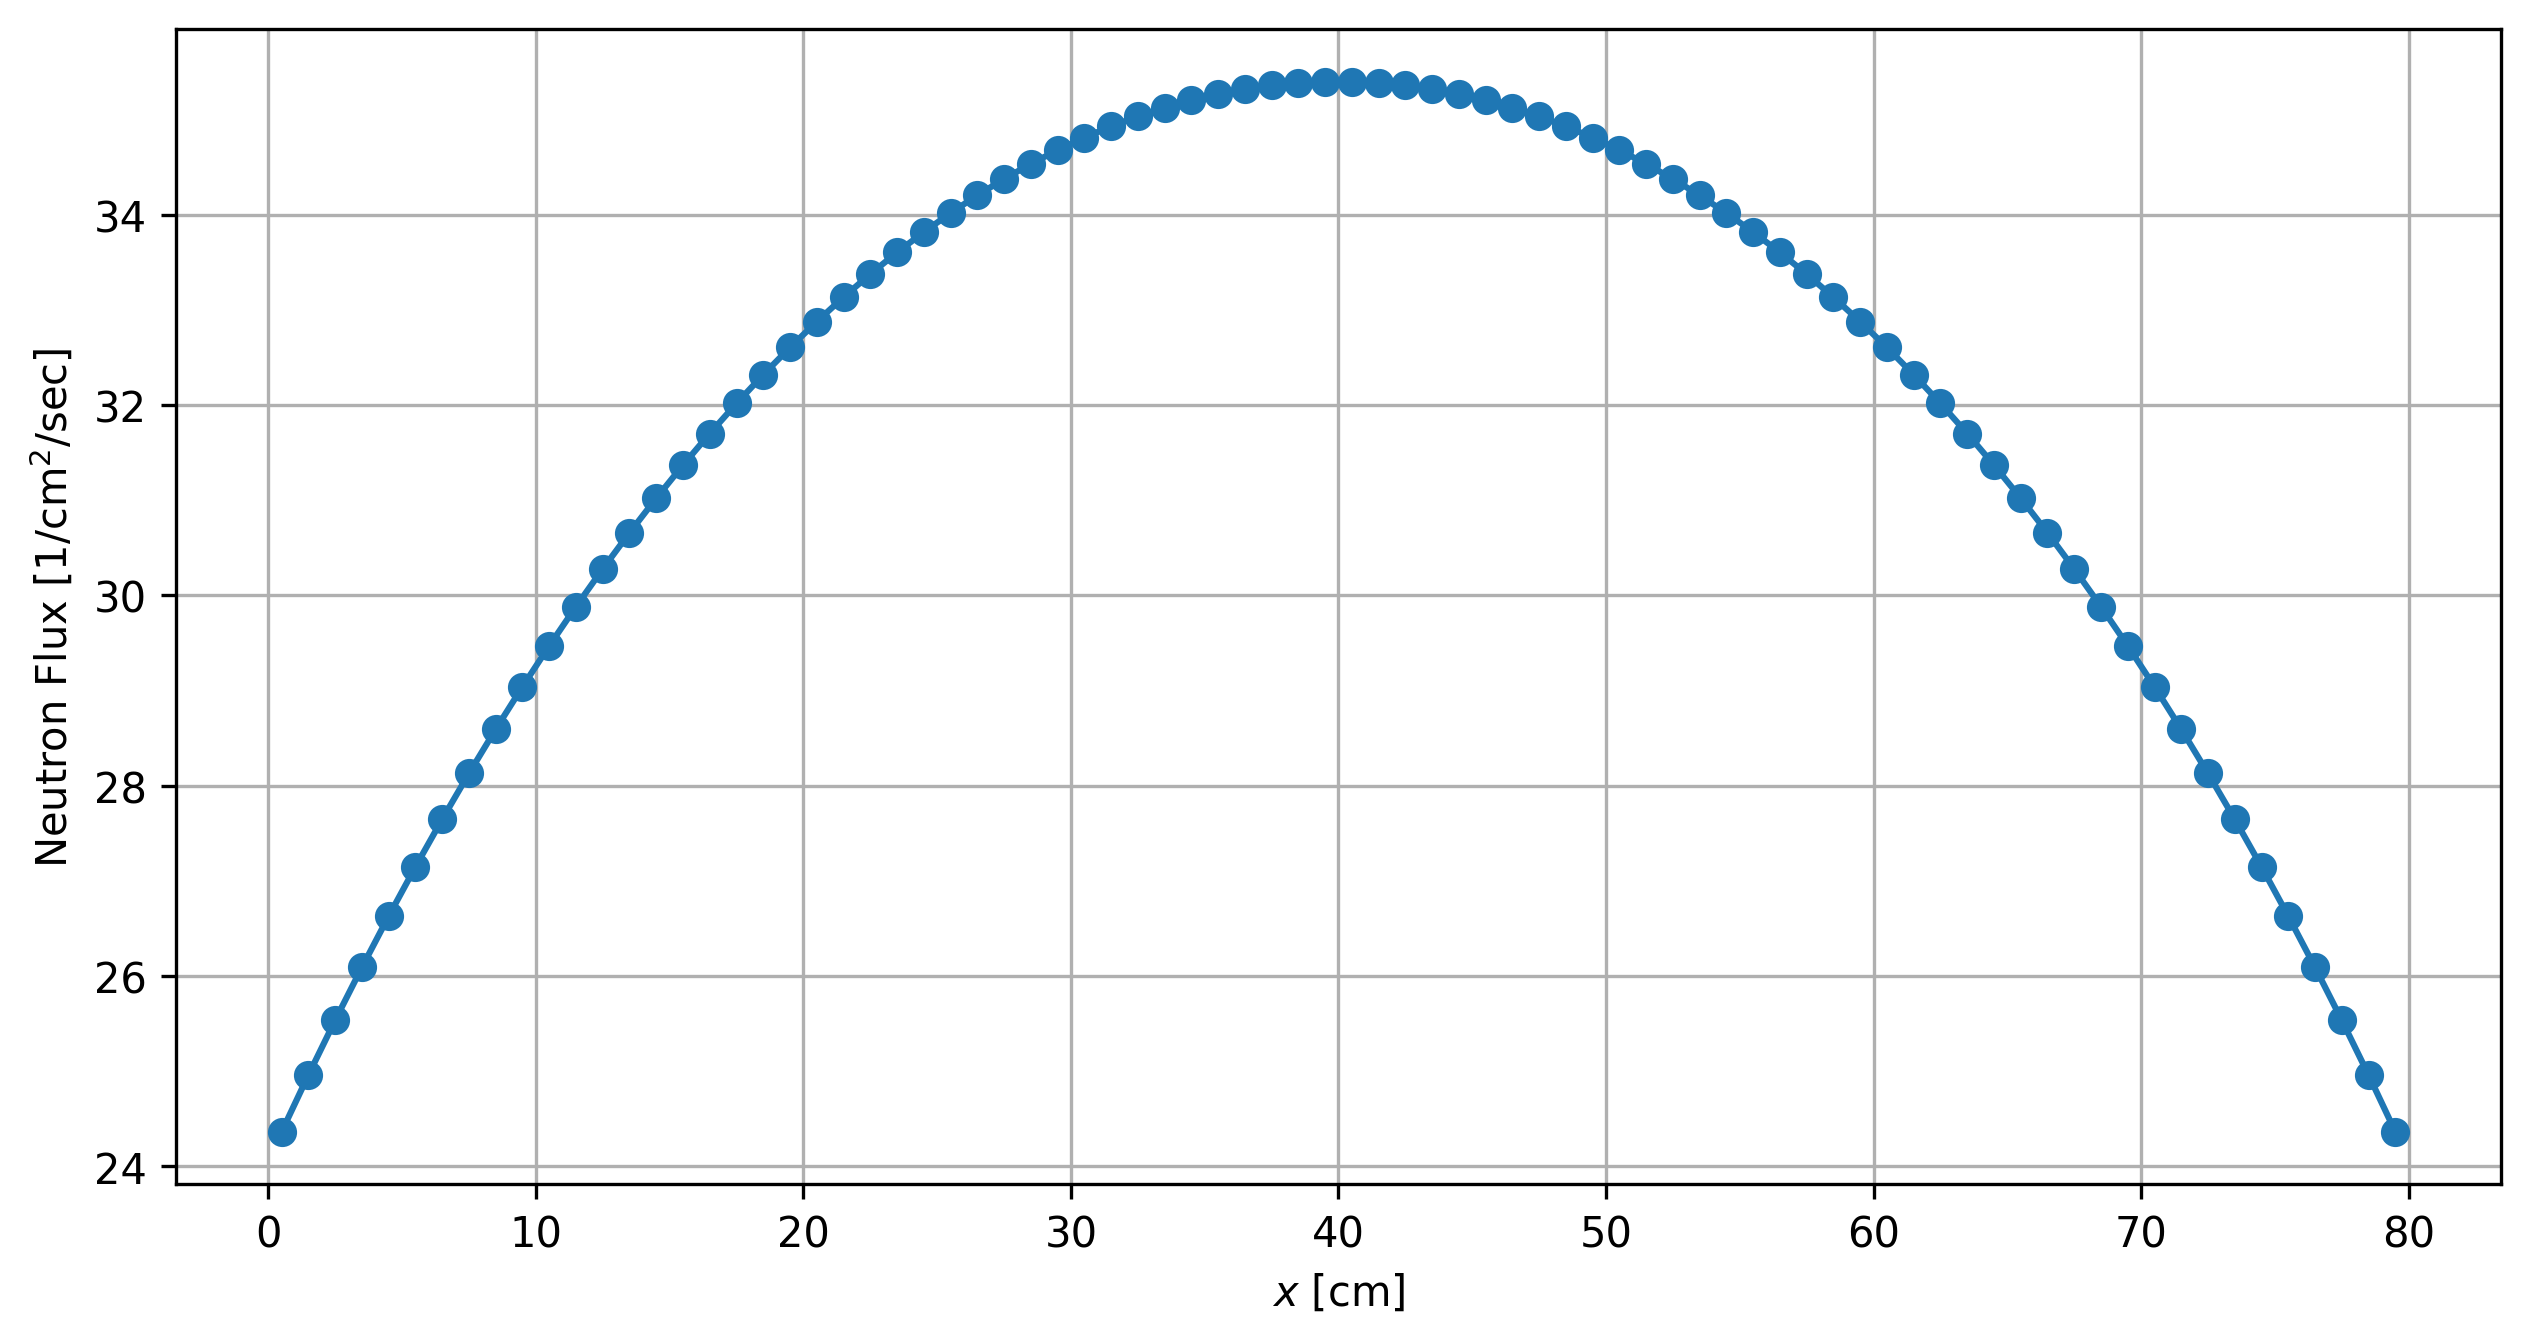

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 要素中心座標
NEL2COORD = np.cumsum(dx) - dx / 2

# 輸送計算
Phi_old = np.ones(NEL)
epsilon = 1e-5
while True:
    Phi, Psi = WDDTransportSweep(SigT, Qm, dx, w, mu)
    if np.max(np.abs(Phi - Phi_old)) < epsilon:
        break
    Phi_old = Phi

# プロット
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel(r'$x$ [cm]')
ax.set_ylabel(r'Neutron Flux [1/cm$^2$/sec]')
ax.plot(NEL2COORD, Phi, label='WDD', marker='o')
plt.grid(True)

plt.show()

Fixed-Source